# **IBL - Fiber Photometry Data**

This tutorial shows how to access data from [DANDI:001772](https://dandiarchive.org/dandiset/001772/draft) for the IBL fiber photometry dataset.

## Study Overview

This dataset contains fiber photometry recordings from mice performing the IBL decision-making task. The experiment investigates the roles of key neuromodulators — dopamine, serotonin, norepinephrine, and acetylcholine — in shaping decision-making and adaptive behavior. Neuromodulatory activity was measured via GCaMP fluorescence across multiple brain regions using chronically implanted optical fibers, with simultaneous isosbestic control recordings to correct for motion artifacts and bleaching.

## Contents

1. [Setup and Data Access](#setup)
2. [Session and Subject Metadata](#metadata)
3. [Fiber Photometry Metadata](#fp_metadata)
4. [Fiber Photometry Data](#data)
5. [Optical Fiber Localization](#loc)

---

# 1. Setup and Data Access <a id="setup"></a>

## Import Required Libraries

In [ ]:
# Core data manipulation and analysis
from pathlib import Path

import h5py

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import remfile
from dandi.dandiapi import DandiAPIClient

# NWB and DANDI access
from pynwb import NWBHDF5IO

# Configure matplotlib
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

## Data Access Functions

In [2]:
def load_nwb_from_dandi(dandiset_id, subject_id, session_id):
    """
    Load NWB file from DANDI Archive via streaming.
    """
    pattern = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}*.nwb"

    with DandiAPIClient() as client:
        client.dandi_authenticate()
        assets = client.get_dandiset(dandiset_id, "draft").get_assets_by_glob(pattern=pattern, order="path")

        s3_urls = []
        for asset in assets:
            s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)
            s3_urls.append(s3_url)

        if len(s3_urls) != 1:
            raise ValueError(f"Expected 1 file, found {len(s3_urls)} for pattern {pattern}")

        s3_url = s3_urls[0]

    file = remfile.File(s3_url)
    h5_file = h5py.File(file, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwbfile = io.read()

    return nwbfile, io


def load_nwb_local(directory_path, subject_id, session_id):
    """
    Load NWB file from local directory.
    """
    directory_path = Path(directory_path)
    nwbfile_path = directory_path / f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_behavior+image.nwb"

    if not nwbfile_path.exists():
        raise FileNotFoundError(f"NWB file not found: {nwbfile_path}")

    io = NWBHDF5IO(path=nwbfile_path, load_namespaces=True)
    nwbfile = io.read()

    return nwbfile, io

---

# 2. Session and Subject Metadata <a id="metadata"></a>

In [3]:
# Load session data
dandiset_id = "001772"  # TODO Replace with actual DANDI dandiset ID
subject_id = "ZFM-08652"  # Example subject
session_id = "fd688232-0dd8-400b-aa66-dc23460d9f98"  # EID for the session


# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id)
else:
    # Specify your local directory path
    local_directory = "E:/IBL-fiberphotometry-nwbfiles/full"  # Replace with actual path
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id)

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 This experiment investigates the distinct roles of key neuromodulators—dopamine, serotonin, norepinephrine, and acetylcholine—in shaping decision-making and adaptive behavior. Using the International Brain Laboratory's standardized decision-making task, which has been validated for reproducibility across behavior and neural recordings, we systematically examine neuromodulatory activity across multiple brain regions and task events. This approach allows us to link neuromodulatory dynamics to learning, behavioral strategy shifts, and theoretical models of decision making. To support this scientific effort, the project includes the development of integrated hardware for high-throughput fiber photometry acquisition, fully compatible with the IBL behavioral platform.
Session description:
 The task protocol(s) performed in this experimental session:
1. Training choice world — the standard IBL training task. Mice learn to turn a wheel to mo

In [4]:
print("=== SUBJECT INFORMATION ===")
print(f"ID: {nwbfile.subject.subject_id}")
print(f"Age: {nwbfile.subject.age}")
print(f"Strain: {nwbfile.subject.species}")
print(f"Genotype: {nwbfile.subject.genotype}")
print(f"Sex: {nwbfile.subject.sex}")

=== SUBJECT INFORMATION ===
ID: ZFM-08652
Age: None
Strain: Mus musculus
Genotype: None
Sex: F


---

# 3. Fiber Photometry Metadata <a id="fp_metadata"></a>

## Fiber Photometry Metadata

In [5]:
print("=== FIBER PHOTOMETRY METADATA ===")
print("All fiber photometry metadata are stored in the fiber_photometry module in lab_meta_data:")
nwbfile.lab_meta_data["fiber_photometry"]

=== FIBER PHOTOMETRY METADATA ===
All fiber photometry metadata are stored in the fiber_photometry module in lab_meta_data:


,location,excitation_wavelength_in_nm,emission_wavelength_in_nm,indicator,optical_fiber,excitation_source,photodetector,dichroic_mirror,emission_filter,excitation_filter
id,,,,,,,,,,
0,LC,470.0,515.0,GCaMP abc.Indicator at 0x2108886224912\nFields:\n description: GCaMP calcium sensor in <location>.\n label: GCaMP\n manufacturer: <manufacturer of the GCaMP>\n,optical_fiber_LC abc.OpticalFiber at 0x2108886230960\nFields:\n description: Chronically implanted optic fiber in LC.\n fiber_insertion: fiber_insertion abc.FiberInsertion at 0x2108886230624\nFields:\n hemisphere: <hemisphere>\n insertion_position_ap_in_mm: 0.0\n insertion_position_dv_in_mm: 0.0\n insertion_position_ml_in_mm: 0.0\n position_reference: <reference point>\n\n model: optical_fiber_model abc.OpticalFiberModel at 0x2108886230288\nFields:\n active_length_in_mm: 0.0\n core_diameter_in_um: 0.0\n description: Chronically implantable optic fiber.\n ferrule_diameter_in_mm: 0.0\n ferrule_name: <ferrule name of the optical fiber>\n manufacturer: <manufacturer of the optical fiber>\n model_number: <model of the optical fiber>\n numerical_aperture: 0.0\n\n serial_number: <serial number of the optical fiber>\n,excitation_source_gcamp_signal abc.ExcitationSource at 0x2108886229952\nFields:\n description: excitation source for the sensor's fluorescence signal (470nm).\n model: excitation_source_model_calcium abc.ExcitationSourceModel at 0x2108886229616\nFields:\n description: excitation source for the sensor's fluorescence signal.\n excitation_mode: one-photon\n manufacturer: <manufacturer of the excitation source>\n model_number: <model number of the excitation source>\n source_type: LED\n wavelength_range_in_nm: [460. 490.]\n\n,photodetector abc.Photodetector at 0x2108886231632\nFields:\n description: <description of the photodetector>\n model: photodetector_model abc.PhotodetectorModel at 0x2108886231296\nFields:\n description: <description of the photodetector model>\n detector_type: <type of the photodetector>\n gain: 0.0\n gain_unit: n.a\n manufacturer: <manufacturer of the photodetector>\n model_number: <model of the photodetector>\n wavelength_range_in_nm: [500. 540.]\n\n serial_number: <serial number of the photodetector>\n,dichroic_mirror abc.DichroicMirror at 0x2108886228608\nFields:\n description: <description of the dichroic mirror>\n model: dichroic_mirror_model abc.DichroicMirrorModel at 0x2108886228272\nFields:\n description: <description of the dichroic mirror model>\n manufacturer: <manufacturer of the dichroic mirror>\n model_number: <model of the dichroic mirror>\n\n serial_number: <serial number of the dichroic mirror>\n,emission_filter abc.BandOpticalFilter at 0x2108886229280\nFields:\n description: <description of emission filter>\n model: emission_filter_model abc.BandOpticalFilterModel at 0x2108886228944\nFields:\n bandwidth_in_nm: 40.0\n center_wavelength_in_nm: 520.0\n description: emission filter model for GCaMP fluorescence signal.\n filter_type: Bandpass\n manufacturer: <manufacturer of the emission filter>\n model_number: <model of the emission filter>\n\n,excitation_filter abc.BandOpticalFilter at 0x2108872581008\nFields:\n description: <description of excitation filter>\n model: excitation_filter_model abc.BandOpticalFilterModel at 0x2108872580688\nFields:\n bandwidth_in_nm: 90.0\n center_wavelength_in_nm: 445.0\n description: excitation filter model for GCaMP fluorescence signal.\n filter_type: Bandpass\n manufacturer: <manufacturer of the excitation filter>\n model_number: <model of the excitation filter>\n\n
1,LC,415.0,515.0,GCaMP abc.Indicator at 0x2108886224912\nFields:\n description: GCaMP calcium sensor in <location>.\n label: GCaMP\n manufacturer: <manufacturer of the GCaMP>\n,optical_fiber_LC abc.OpticalFiber at 0x2108886230960\nFields:\n description: Chronically implanted optic fiber in LC.\n fiber_insertion: fiber_insertion abc.FiberInsertion at 0x2108886230624\nFields:\n hemisphere: <hemisphere>\n insertion_position_ap_in_mm: 0.0\n

## Optical Setup Devices

The fiber photometry hardware is stored as NWB `Device` objects. The setup consists of:

| Device | Role |
|--------|------|
| `excitation_source_gcamp_signal` | 470 nm LED — excites Ca²⁺-bound GCaMP |
| `excitation_source_isosbestic_control` | 415 nm LED — excites GCaMP at its Ca²⁺-independent (isosbestic) point |
| `excitation_filter` | Bandpass filter on the excitation path |
| `emission_filter` | Bandpass filter (~520 nm) selecting GCaMP emission |
| `dichroic_mirror` | Separates excitation and emission light paths |
| `photodetector` | Collects the emission signal |
| `optical_fiber_LC` | Chronically implanted fiber targeting locus coeruleus (LC) |

In [6]:
# Excitation sources — GCaMP signal (470 nm) and isosbestic control (415 nm)
print("--- Excitation source: GCaMP signal (470 nm) ---")
print(nwbfile.devices["excitation_source_gcamp_signal"])

print("\n--- Excitation source: Isosbestic control (415 nm) ---")
print(nwbfile.devices["excitation_source_isosbestic_control"])

--- Excitation source: GCaMP signal (470 nm) ---
excitation_source_gcamp_signal abc.ExcitationSource at 0x2108886229952
Fields:
  description: excitation source for the sensor's fluorescence signal (470nm).
  model: excitation_source_model_calcium abc.ExcitationSourceModel at 0x2108886229616
Fields:
  description: excitation source for the sensor's fluorescence signal.
  excitation_mode: one-photon
  manufacturer: <manufacturer of the excitation source>
  model_number: <model number of the excitation source>
  source_type: LED
  wavelength_range_in_nm: [460. 490.]



--- Excitation source: Isosbestic control (415 nm) ---
excitation_source_isosbestic_control abc.ExcitationSource at 0x2108872581968
Fields:
  description: excitation source for the sensor's isosbestic control (415nm).
  model: excitation_source_model_isosbestic abc.ExcitationSourceModel at 0x2108872581648
Fields:
  description: excitation source for the sensor's isosbestic control.
  excitation_mode: one-photon
  manufactu

In [7]:
# Optical filters and dichroic mirror
print("--- Excitation filter ---")
print(nwbfile.devices["excitation_filter"])

print("\n--- Emission filter ---")
print(nwbfile.devices["emission_filter"])

print("\n--- Dichroic mirror ---")
print(nwbfile.devices["dichroic_mirror"])

--- Excitation filter ---
excitation_filter abc.BandOpticalFilter at 0x2108872581008
Fields:
  description: <description of excitation filter>
  model: excitation_filter_model abc.BandOpticalFilterModel at 0x2108872580688
Fields:
  bandwidth_in_nm: 90.0
  center_wavelength_in_nm: 445.0
  description: excitation filter model for GCaMP fluorescence signal.
  filter_type: Bandpass
  manufacturer: <manufacturer of the excitation filter>
  model_number: <model of the excitation filter>



--- Emission filter ---
emission_filter abc.BandOpticalFilter at 0x2108886229280
Fields:
  description: <description of emission filter>
  model: emission_filter_model abc.BandOpticalFilterModel at 0x2108886228944
Fields:
  bandwidth_in_nm: 40.0
  center_wavelength_in_nm: 520.0
  description: emission filter model for GCaMP fluorescence signal.
  filter_type: Bandpass
  manufacturer: <manufacturer of the emission filter>
  model_number: <model of the emission filter>



--- Dichroic mirror ---
dichroic_mir

In [8]:
# Photodetector and implanted optical fiber
print("--- Photodetector ---")
print(nwbfile.devices["photodetector"])

print("\n--- Implanted optical fiber ---")
optical_fiber = next(v for k, v in nwbfile.devices.items() if "optical_fiber" in k)
print(optical_fiber)

--- Photodetector ---
photodetector abc.Photodetector at 0x2108886231632
Fields:
  description: <description of the photodetector>
  model: photodetector_model abc.PhotodetectorModel at 0x2108886231296
Fields:
  description: <description of the photodetector model>
  detector_type: <type of the photodetector>
  gain: 0.0
  gain_unit: n.a
  manufacturer: <manufacturer of the photodetector>
  model_number: <model of the photodetector>
  wavelength_range_in_nm: [500. 540.]

  serial_number: <serial number of the photodetector>


--- Implanted optical fiber ---
optical_fiber_LC abc.OpticalFiber at 0x2108886230960
Fields:
  description: Chronically implanted optic fiber in LC.
  fiber_insertion: fiber_insertion abc.FiberInsertion at 0x2108886230624
Fields:
  hemisphere: <hemisphere>
  insertion_position_ap_in_mm: 0.0
  insertion_position_dv_in_mm: 0.0
  insertion_position_ml_in_mm: 0.0
  position_reference: <reference point>

  model: optical_fiber_model abc.OpticalFiberModel at 0x210888623

In [9]:
print("=== FLUORESCENT CALCIUM SENSOR ===")
print("Fluorescent calcium sensor used in this experiment:")
nwbfile.lab_meta_data["fiber_photometry"].fiber_photometry_indicators

=== FLUORESCENT CALCIUM SENSOR ===
Fluorescent calcium sensor used in this experiment:


fiber_photometry_indicators abc.FiberPhotometryIndicators at 0x2108886225248
Fields:
  indicators: {
    GCaMP <class 'abc.Indicator'>
  }

---

# 4. Fiber Photometry Data <a id="data"></a>

## FiberPhotometryTable

The `FiberPhotometryTable` links each data series to its experimental context — which optical fiber, indicator, excitation source, and emission filter were used. Each row corresponds to one recording channel.

In [10]:
# Display the FiberPhotometryTable as a DataFrame
fp_table = nwbfile.lab_meta_data["fiber_photometry"].fiber_photometry_table
fp_df = fp_table.to_dataframe()
fp_df

,location,excitation_wavelength_in_nm,emission_wavelength_in_nm,indicator,optical_fiber,excitation_source,photodetector,dichroic_mirror,emission_filter,excitation_filter
id,,,,,,,,,,
0,LC,470.0,515.0,GCaMP abc.Indicator at 0x2108886224912\nFields...,optical_fiber_LC abc.OpticalFiber at 0x2108886...,excitation_source_gcamp_signal abc.ExcitationS...,photodetector abc.Photodetector at 0x210888623...,dichroic_mirror abc.DichroicMirror at 0x210888...,emission_filter abc.BandOpticalFilter at 0x210...,excitation_filter abc.BandOpticalFilter at 0x2...
1,LC,415.0,515.0,GCaMP abc.Indicator at 0x2108886224912\nFields...,optical_fiber_LC abc.OpticalFiber at 0x2108886...,excitation_source_isosbestic_control abc.Excit...,photodetector abc.Photodetector at 0x210888623...,dichroic_mirror abc.DichroicMirror at 0x210888...,emission_filter abc.BandOpticalFilter at 0x210...,excitation_filter abc.BandOpticalFilter at 0x2...


## FiberPhotometrySeries

The raw fluorescence time series are stored in `nwbfile.acquisition`. Two channels are recorded simultaneously using frequency-division multiplexing:

- **GCaMP signal** (470 nm excitation): reflects Ca²⁺-dependent fluorescence changes, including neural activity and motion artifacts.
- **Isosbestic control** (415 nm excitation): reflects Ca²⁺-independent changes (e.g., motion, bleaching) and is used to correct the GCaMP signal.

In [11]:
print("=== ACQUISITION MODULE ===\n")
for name, acq in nwbfile.acquisition.items():
    if "signal" in name:
        print("-"*20)
        print(f"Name: {acq.name}")
        print(f"Description: {acq.description}")
        print(f"Metadata:")
        fp_metadata = acq.fiber_photometry_table_region[:]
        print(f"  Location: {fp_metadata['location'].values[0]}")
        print(f"  Excitation wavelength: {fp_metadata['excitation_wavelength_in_nm'].values[0]} nm")

=== ACQUISITION MODULE ===

--------------------
Name: gcamp_signal
Description: The fluorescence signal from GCaMP Ca2+ bound emission.
Metadata:
  Location: LC
  Excitation wavelength: 470.0 nm
--------------------
Name: isosbestic_signal
Description: The fluorescence signal from GCaMP Ca2+ independent emission (isosbestic signal).
Metadata:
  Location: LC
  Excitation wavelength: 415.0 nm


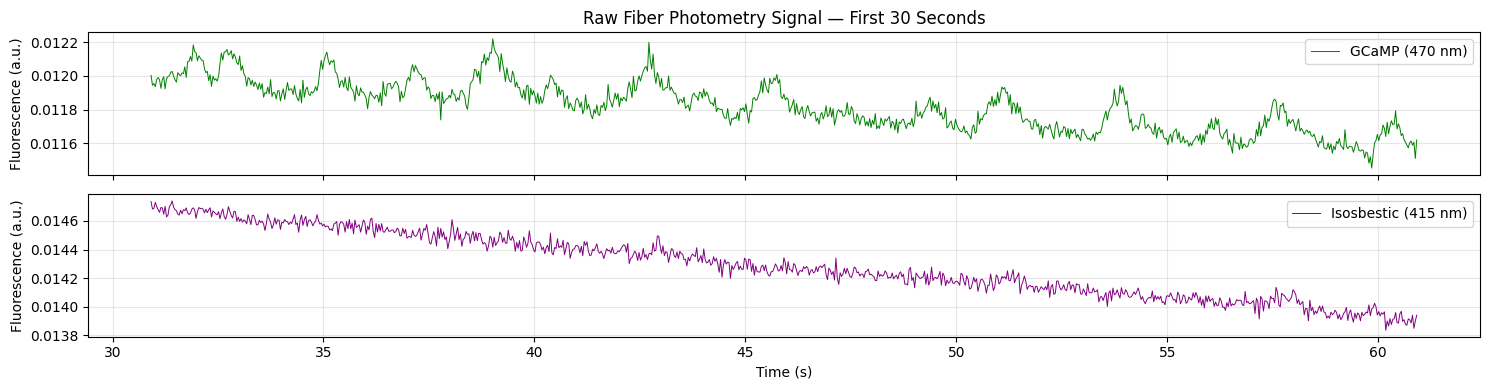

Sampling rate: 30.0 Hz
Total duration: 5407.1 s


In [12]:
gcamp_signal = nwbfile.acquisition["gcamp_signal"]
isosbestic_signal = nwbfile.acquisition["isosbestic_signal"]
timestamps = gcamp_signal.timestamps[:]

# Limit to first 30 seconds for readability
mask = timestamps <= timestamps[0] + 30
t = timestamps[mask]

fig, axes = plt.subplots(2, 1, figsize=(15, 4), sharex=True)

axes[0].plot(t, gcamp_signal.data[:len(t)], linewidth=0.7, color="green", label="GCaMP (470 nm)")
axes[0].set_ylabel("Fluorescence (a.u.)")
axes[0].set_title("Raw Fiber Photometry Signal — First 30 Seconds")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, isosbestic_signal.data[:len(t)], linewidth=0.7, color="purple", label="Isosbestic (415 nm)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Fluorescence (a.u.)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sampling rate: {1 / np.median(np.diff(timestamps)):.1f} Hz")
print(f"Total duration: {timestamps[-1] - timestamps[0]:.1f} s")

---

# 5. Optical Fiber Localization <a id="loc"></a>

The anatomical location of each implanted fiber tip is stored in `nwbfile.lab_meta_data["localization"]` using the `ndx-anatomical-localization` extension.

Two coordinate tables are provided per fiber:
- **`AnatomicalCoordinatesIBLBregmaOpticalFibers`** — coordinates in IBL-Bregma space (origin at bregma, RAS orientation, units: µm)
- **`AnatomicalCoordinatesCCFv3OpticalFibers`** — coordinates registered to the Allen Common Coordinate Framework v3 (units: µm)

In [13]:
localization = nwbfile.lab_meta_data["localization"]

print("Coordinate spaces available:")
for space_name in localization.spaces:
    print(f"  - {space_name}")

print("\nAnatomical coordinate tables:")
for table_name, table in localization.anatomical_coordinates_tables.items():
    print(f"\n  {table_name}")
    print(f"    Description: {table.description}")
    print(f"    Method: {table.method}")
    df = table.to_dataframe()
    display(df)

Coordinate spaces available:
  - AllenCCFv3
  - IBLBregma

Anatomical coordinate tables:

  AnatomicalCoordinatesCCFv3OpticalFibers
    Description: Fiber tip positions in the Allen CCF v3 coordinate system (units: um). One row per unique OpticalFiber. The localized_entity column references the first FiberPhotometryTable row index associated with each fiber, since multiple rows (e.g., different excitation wavelengths) can share the same physical fiber.
    Method: TODO: IBL histology / atlas registration pipeline for fiber photometry


,x,y,z,localized_entity,brain_region
id,,,,,
0,NaN,NaN,NaN,location excitation_wavelength_in_nm emis...,TODO



  AnatomicalCoordinatesIBLBregmaOpticalFibers
    Description: Fiber tip positions in the IBL-Bregma coordinate system (origin at bregma, units: um, RAS). One row per unique OpticalFiber. The localized_entity column references the first FiberPhotometryTable row index associated with each fiber, since multiple rows (e.g., different excitation wavelengths) can share the same physical fiber.
    Method: TODO: IBL histology / atlas registration pipeline for fiber photometry


,x,y,z,localized_entity,brain_region
id,,,,,
0,NaN,NaN,NaN,location excitation_wavelength_in_nm emis...,TODO
